# External validation on mcPHASES (hormonal ground truth)

The HSMM in `02_model_hsmm.ipynb` and the change-point in `01_discovery.ipynb`
were only ever checked against **Garmin's own calendar rule** — agreement between two
algorithms, not against truth. The [mcPHASES](https://physionet.org/content/mcphases/)
dataset fixes that: 42 participants with Fitbit biometrics **and** Mira hormone assays
(LH, estrogen/E3G, PdG) over ~90-day intervals, so we can score the model's follicular→luteal
boundary against the **LH surge** — the physiological ovulation marker.

**Project statement clarified.** The model estimates the **wearable follicular→luteal biometric transition**. The LH peak is the hormonal ovulation marker; the model boundary is expected to be later when RHR/HRV/respiration respond after the hormonal event.

**Signal mapping (Fitbit → our Garmin schema).** `resting_hr ← resting_heart_rate`,
`hrv_rmssd ← nightly mean of HRV rmssd`, `avg_sleep_respiration ← full-sleep breathing rate`.
Garmin's `avg_sleep_stress` has **no clean Fitbit equivalent**, so the model runs on the
remaining **three** signals here.

**Truth.** Per cycle, ovulation = **LH-peak day** (gated by a surge test), extracted by
`analysis/mcphases_truth.py`. Because the biometric luteal onset physiologically *lags* true
ovulation by the progesterone/RHR delay, we expect the model boundary `b` to land a couple of
days **after** the LH peak — so we report both the raw offset and a bias-corrected precision.

**Emissions.** Signals are robust-standardized **per person** (median/MAD), which removes
cross-person scale, so emission parameters can be **pooled across participants** (the shared
follicular↔luteal *shape*). This is the design intended for the future multi-person Garmin
collector. We show pooled (primary) and per-person side by side.


In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "analysis").exists():
    REPO_ROOT = Path("/home/elsa/projects/garmin")
sys.path.insert(0, str(REPO_ROOT / "analysis"))   # make the `cyclelib` package importable

# Ground truth + biometric prep for mcPHASES (moved into cyclelib/truth_mcphases.py).
from cyclelib.truth_mcphases import (build_daily_table, add_cycle_structure,
                                     extract_ovulation_truth, SIGNALS)

MCPHASES_DIR = REPO_ROOT / "data/external/physionet.org/files/mcphases/1.0.0"
CACHE = REPO_ROOT / "data/external/mcphases_daily.csv"

daily = build_daily_table(MCPHASES_DIR, cache_path=CACHE)   # cached for re-runs
df = add_cycle_structure(daily)
truth = extract_ovulation_truth(df)

SIG = SIGNALS                 # resting_hr, hrv_rmssd, avg_sleep_respiration
D = len(SIG)
comp = truth[truth["cycle_len"].notna()]
conf = comp[comp["confident"]]
print(f"participants: {df['id'].nunique()} | complete cycles: {len(comp)} | "
      f"confident LH surge: {len(conf)} ({len(conf)/len(comp)*100:.0f}%)")
print("signal coverage:", {s: f"{daily[s].notna().mean()*100:.0f}%" for s in SIG})
print("zero-sentinel counts:", {s: int((daily[s] <= 0).sum()) for s in SIG})


## Ground truth — and a first independent check

Two facts fall out of the hormonal truth before any model runs:

- **Hormonal luteal length ≈ 13–14 days** (median 14, mean 13.3, std 3.3). This *independently*
  confirms the `DUR_MU = 13` luteal-duration prior and the HSMM's median-13 output — Garmin's
  calendar rule and real hormones now agree, so the prior is not circular.
- **The study's own `Luteal` label starts ~3 days after the LH peak** — the biometric lag we
  expect the model boundary to inherit.


In [2]:
print("Hormonal luteal length (cycle_len - LH-peak day):")
print(f"   median {conf['luteal_len'].median():.0f}  mean {conf['luteal_len'].mean():.1f}  "
      f"std {conf['luteal_len'].std():.1f}")
print(f"True ovulation (LH-peak) cycle_day: median {conf['ov_day'].median():.0f}  "
      f"IQR {conf['ov_day'].quantile(.25):.0f}-{conf['ov_day'].quantile(.75):.0f}")
print(f"phase Luteal-onset  -  LH-peak day: median {(conf['luteal_onset']-conf['ov_day']).median():.1f} d (biometric lag)")
conf.head(8)


Hormonal luteal length (cycle_len - LH-peak day):
   median 14  mean 13.3  std 3.3
True ovulation (LH-peak) cycle_day: median 16  IQR 14-19
phase Luteal-onset  -  LH-peak day: median 3.0 d (biometric lag)


,id,study_interval,cycle_id,cycle_len,confident,ov_day,lh_peak,lh_prominence,luteal_onset,luteal_len
0,1,2022,1,30,True,14,46.1,16.5,16.0,16
2,2,2022,1,31,True,15,29.1,8.8,18.0,16
3,2,2022,2,32,True,16,40.2,12.8,19.0,16
4,3,2022,1,33,True,20,24.5,5.9,22.0,13
7,4,2022,2,34,True,18,36.7,9.4,21.0,16
10,6,2022,2,32,True,19,42.0,3.9,21.0,13
11,7,2022,1,27,True,13,47.5,14.8,16.0,14
12,7,2022,2,31,True,15,49.9,15.1,18.0,16


## The model — same HSMM, transferred verbatim

Exactly the `02_model_hsmm.ipynb` recipe: per-person robust standardization; follicular
emission seeded from the **post-menstrual window** `[period_end, period_end+6)`; luteal emission
from the last 6 pre-menstrual days; per-cycle MAP boundary with the soft luteal-duration prior.
The only differences are three signals instead of four (no sleep-stress) and that emissions can
be **pooled** across participants.


In [ ]:
# The HSMM is now imported from cyclelib (same code as 02_model_hsmm), not re-pasted.
# The only notebook-local glue is the mcPHASES grouping (id, study_interval, cycle_id)
# and per-person standardization; the model itself lives in the library.
from cyclelib.hsmm import (fit_gaussian, segment_gaussian, boundary_search,
                           BoundaryWindow, DurationPrior)
from cyclelib.emissions import anchor_rows as _anchor_rows, clean_anchors, AnchorConfig
from cyclelib.features import standardize_per_group

ZCOLS = [f"z_{s}" for s in SIG]
WINDOW = BoundaryWindow(min_after=4, min_lut=4, max_lut=19)
PRIOR = DurationPrior(mu=13.0, sd=2.5)
ANCHOR = AnchorConfig(foll_width=6, foll_guard=16, lut_width=6)


def standardize_per_person(df):
    return standardize_per_group(df, SIG, ["id", "study_interval"])


def cycle_iter(df):
    for keys, gc in df.groupby(["id", "study_interval", "cycle_id"], sort=False):
        if pd.isna(gc["cycle_len"].iloc[0]):
            continue
        yield keys, gc.sort_values("cycle_day")


def anchor_rows(df):
    return _anchor_rows((gc for _, gc in cycle_iter(df)), SIG, ANCHOR)


def fit(sub):
    """Gaussian emissions from anchor days; None if too few clean rows."""
    F, L = clean_anchors(*anchor_rows(sub))
    return fit_gaussian(F, L)


def segment(gc, em, use_dur=True):
    r = segment_gaussian(gc["cycle_day"].to_numpy(), gc["is_period"].to_numpy(),
                         int(gc["period_end"].iloc[0]), int(gc["cycle_len"].iloc[0]),
                         gc[ZCOLS].to_numpy(), em,
                         window=WINDOW, prior=PRIOR, use_duration=use_dur)
    return None if r is None else r["transition_day"]


def run(dfz, emission="pooled", use_dur=True):
    pooled = fit(dfz) if emission == "pooled" else None
    rows = []
    for (pid, iv), gb in dfz.groupby(["id", "study_interval"], sort=False):
        em = pooled if emission == "pooled" else fit(gb)
        if em is None:
            continue
        for keys, gc in cycle_iter(gb):
            b = segment(gc, em, use_dur)
            if b is not None:
                rows.append({"id": pid, "study_interval": iv, "cycle_id": keys[2],
                             "cycle_len": int(gc["cycle_len"].iloc[0]), "b": b})
    res = pd.DataFrame(rows).merge(
        truth[["id", "study_interval", "cycle_id", "ov_day", "luteal_onset", "confident"]],
        on=["id", "study_interval", "cycle_id"], how="left")
    return res[res["confident"] == True]        # noqa: E712


dfz = standardize_per_person(df)
POOLED_EM = fit(dfz)
print("Pooled emission means (per-person-standardized units):")
print("  follicular:", dict(zip(SIG, POOLED_EM[0].round(2))))
print("  luteal    :", dict(zip(SIG, POOLED_EM[2].round(2))))


In [4]:
def metrics(res, truth_col):
    d = (res["b"] - res[truth_col]).dropna()
    dc = d - d.median()
    return {"n": len(d), "bias": round(d.median(), 1),
            "MAD": round(dc.abs().median(), 1),
            "within2d": round((d.abs() <= 2).mean() * 100),
            "within3d": round((d.abs() <= 3).mean() * 100),
            "within2d_bc": round((dc.abs() <= 2).mean() * 100),
            "within3d_bc": round((dc.abs() <= 3).mean() * 100)}

res_person = run(dfz, "per-person")
res_pooled = run(dfz, "pooled")

print("Boundary b  vs  TRUE ovulation (LH peak)   [bias = biometric lag; _bc = bias-corrected]")
for name, r in [("per-person emissions", res_person), ("pooled emissions", res_pooled)]:
    print(f"  {name:22s}", metrics(r, "ov_day"))
print("\nBoundary b  vs  phase LUTEAL-ONSET label")
for name, r in [("per-person emissions", res_person), ("pooled emissions", res_pooled)]:
    print(f"  {name:22s}", metrics(r, "luteal_onset"))
print("\nFor reference, vs Garmin's calendar rule on the owner's single record: within-2d ~65%.")


Boundary b  vs  TRUE ovulation (LH peak)   [bias = biometric lag; _bc = bias-corrected]
  per-person emissions   {'n': 86, 'bias': np.float64(2.0), 'MAD': np.float64(3.0), 'within2d': 40, 'within3d': 51, 'within2d_bc': 42, 'within3d_bc': 55}
  pooled emissions       {'n': 90, 'bias': np.float64(3.5), 'MAD': np.float64(1.5), 'within2d': 31, 'within3d': 42, 'within2d_bc': 51, 'within3d_bc': 72}

Boundary b  vs  phase LUTEAL-ONSET label
  per-person emissions   {'n': 84, 'bias': np.float64(-2.0), 'MAD': np.float64(3.0), 'within2d': 42, 'within3d': 55, 'within2d_bc': 42, 'within3d_bc': 54}
  pooled emissions       {'n': 88, 'bias': np.float64(0.0), 'MAD': np.float64(2.0), 'within2d': 65, 'within3d': 80, 'within2d_bc': 65, 'within3d_bc': 80}

For reference, vs Garmin's calendar rule on the owner's single record: within-2d ~65%.


## Diagnostics

The HSMM boundary `b` is interpreted as the **wearable biometric luteal transition**, so the
primary validation target is the study's labelled **luteal onset**. The LH peak is shown
separately because it is the hormonal ovulation marker that usually occurs a few days earlier.

Left: raw offset from LH peak, showing the physiological lag. Middle: raw offset from labelled
luteal onset, showing whether the boundary matches the transition label. Right: pooled emission
means, a physiological direction check.


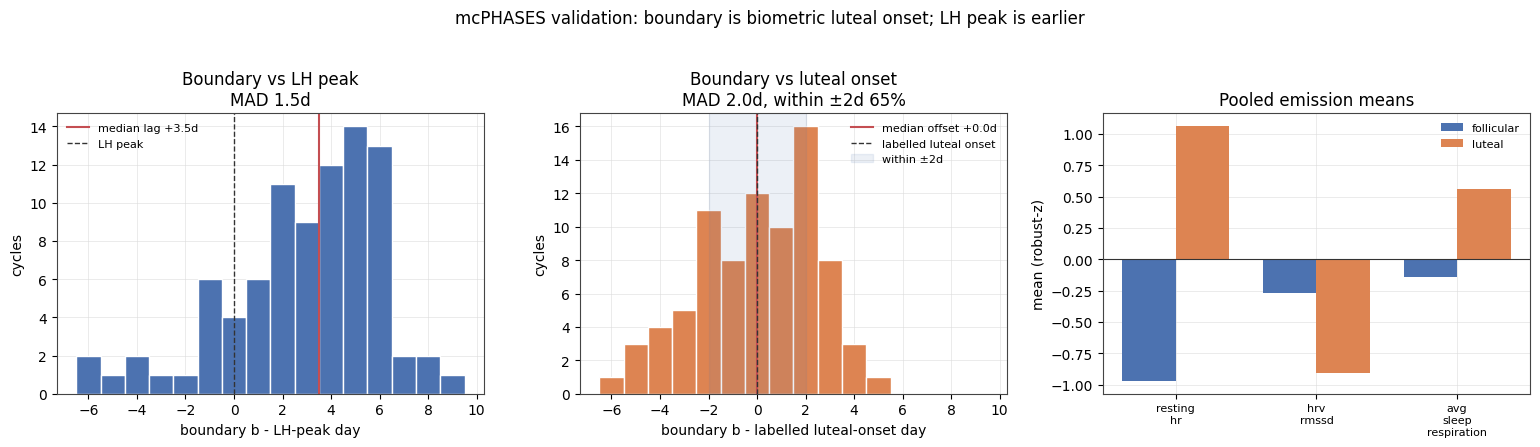

In [5]:
plt.style.use("default")
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))
fig.set_facecolor("white")

for ax in axes:
    ax.set_facecolor("white")
    ax.tick_params(axis="both", colors="black", labelcolor="black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")
    for spine in ax.spines.values():
        spine.set_color("#444444")
    ax.grid(True, color="#dddddd", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

# 1) Boundary vs hormonal LH peak: this shows the lag from true ovulation marker.
d_lh = (res_pooled["b"] - res_pooled["ov_day"]).dropna()
axes[0].hist(d_lh, bins=np.arange(-6.5, 9.6, 1), color="#4c72b0", edgecolor="white")
axes[0].axvline(d_lh.median(), color="#c44e52", lw=1.5,
                label=f"median lag {d_lh.median():+.1f}d")
axes[0].axvline(0, color="#333333", ls="--", lw=1, label="LH peak")
axes[0].set_xlabel("boundary b - LH-peak day")
axes[0].set_ylabel("cycles")
axes[0].set_title(f"Boundary vs LH peak\nMAD {(d_lh - d_lh.median()).abs().median():.1f}d")
axes[0].legend(frameon=False, fontsize=8)

# 2) Boundary vs labelled luteal onset: this is the direct transition comparison.
d_lut = (res_pooled["b"] - res_pooled["luteal_onset"]).dropna()
axes[1].hist(d_lut, bins=np.arange(-6.5, 9.6, 1), color="#dd8452", edgecolor="white")
axes[1].axvline(d_lut.median(), color="#c44e52", lw=1.5,
                label=f"median offset {d_lut.median():+.1f}d")
axes[1].axvline(0, color="#333333", ls="--", lw=1, label="labelled luteal onset")
axes[1].axvspan(-2, 2, color="#4c72b0", alpha=0.10, label="within ±2d")
axes[1].set_xlabel("boundary b - labelled luteal-onset day")
axes[1].set_ylabel("cycles")
axes[1].set_title(f"Boundary vs luteal onset\nMAD {(d_lut - d_lut.median()).abs().median():.1f}d, within ±2d {(d_lut.abs() <= 2).mean() * 100:.0f}%")
axes[1].legend(frameon=False, fontsize=8)

# 3) Emission direction check.
muF, _, muL, _ = POOLED_EM
x = np.arange(len(SIG))
w = 0.38
axes[2].bar(x - w / 2, muF, w, label="follicular", color="#4c72b0")
axes[2].bar(x + w / 2, muL, w, label="luteal", color="#dd8452")
axes[2].axhline(0, color="#333333", lw=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels([s.replace("_", "\n") for s in SIG], fontsize=8, color="black")
axes[2].set_ylabel("mean (robust-z)")
axes[2].set_title("Pooled emission means")
axes[2].legend(frameon=False, fontsize=8)

fig.suptitle("mcPHASES validation: boundary is biometric luteal onset; LH peak is earlier", y=1.03, color="black")
fig.tight_layout()
plt.show()


## Discriminative emissions — `P(luteal | features)` in place of the Gaussian

This is next-step lever #4, built **alongside** (not replacing) the Gaussian version above. The HSMM
skeleton is untouched — same single boundary, same feasibility window, same soft luteal-duration
prior, same per-cycle MAP search. **Only the per-day emission changes:**

- *Generative (above):* `logmvn(x | state)` — one Gaussian bell per state, scored by likelihood.
- *Discriminative (here):* a logistic regression trained on the same follicular/luteal anchor days
  outputs `p = P(luteal | x)`; the emission becomes `log(1 - p)` on follicular days and `log(p)` on
  luteal days. This is the classifier idea from `01_discovery.ipynb` (Steps 1–2), but its
  day-scores are now consumed by the HSMM's boundary + duration machinery instead of a *post-hoc*
  change-point on the probability trajectory.

To isolate the emission model, the classifier is trained on the **same per-person-standardized
signals** (`z_*`) the Gaussian uses — so any difference is the emission, not the features. (Mild
caveat: like the pooled Gaussian, the pooled classifier is fit on all anchor endpoints; the boundary
itself lives in the unlabeled mid-cycle days, so that endpoint reuse barely touches the estimate.)


In [ ]:
# Discriminative emission from cyclelib: same anchors, same boundary search,
# only P(luteal | z) replaces the Gaussian. See cyclelib/emissions.py.
from cyclelib.emissions import fit_discriminative, discriminative_logscores


def fit_disc(sub):
    """P(luteal | z) logistic regression from this subframe's follicular/luteal anchors."""
    return fit_discriminative(*anchor_rows(sub))


def segment_disc(gc, clf, use_dur=True):
    """Same boundary search as `segment`; only the per-day emission changes.

    The Gaussian `logmvn(x | state)` is replaced by the classifier's log-posterior:
    ``log(1 - p)`` on follicular days and ``log(p)`` on luteal days, where
    ``p = P(luteal | x)``. Feasibility window and luteal-duration prior are identical.
    """
    Xc = gc[ZCOLS].to_numpy()
    if np.isnan(Xc).any():
        return None
    lF, lL = discriminative_logscores(Xc, clf)
    r = boundary_search(gc["cycle_day"].to_numpy(), gc["is_period"].to_numpy(),
                        int(gc["period_end"].iloc[0]), int(gc["cycle_len"].iloc[0]),
                        lF, lL, window=WINDOW, prior=PRIOR, use_duration=use_dur)
    return None if r is None else r["transition_day"]


def run_disc(dfz, emission="pooled", use_dur=True):
    pooled = fit_disc(dfz) if emission == "pooled" else None
    rows = []
    for (pid, iv), gb in dfz.groupby(["id", "study_interval"], sort=False):
        clf = pooled if emission == "pooled" else fit_disc(gb)
        if clf is None:
            continue
        for keys, gc in cycle_iter(gb):
            b = segment_disc(gc, clf, use_dur)
            if b is not None:
                rows.append({"id": pid, "study_interval": iv, "cycle_id": keys[2],
                             "cycle_len": int(gc["cycle_len"].iloc[0]), "b": b})
    res = pd.DataFrame(rows).merge(
        truth[["id", "study_interval", "cycle_id", "ov_day", "luteal_onset", "confident"]],
        on=["id", "study_interval", "cycle_id"], how="left")
    return res[res["confident"] == True]        # noqa: E712


res_person_disc = run_disc(dfz, "per-person")
res_pooled_disc = run_disc(dfz, "pooled")

print("DISCRIMINATIVE emissions  --  Boundary b  vs  TRUE ovulation (LH peak)")
for name, r in [("per-person", res_person_disc), ("pooled", res_pooled_disc)]:
    print(f"  {name:12s}", metrics(r, "ov_day"))
print("\nDISCRIMINATIVE emissions  --  Boundary b  vs  phase LUTEAL-ONSET label")
for name, r in [("per-person", res_person_disc), ("pooled", res_pooled_disc)]:
    print(f"  {name:12s}", metrics(r, "luteal_onset"))


Pooled emissions — Gaussian vs Discriminative:
                                n  bias  MAD  within2d  within3d  within2d_bc  \
LH peak      Gaussian        90.0   3.5  1.5      31.0      42.0         51.0   
             Discriminative  90.0   1.0  2.0      57.0      70.0         57.0   
Luteal onset Gaussian        88.0   0.0  2.0      65.0      80.0         65.0   
             Discriminative  88.0  -2.5  2.5      47.0      62.0         47.0   

                             within3d_bc  
LH peak      Gaussian               72.0  
             Discriminative         71.0  
Luteal onset Gaussian               80.0  
             Discriminative         68.0  


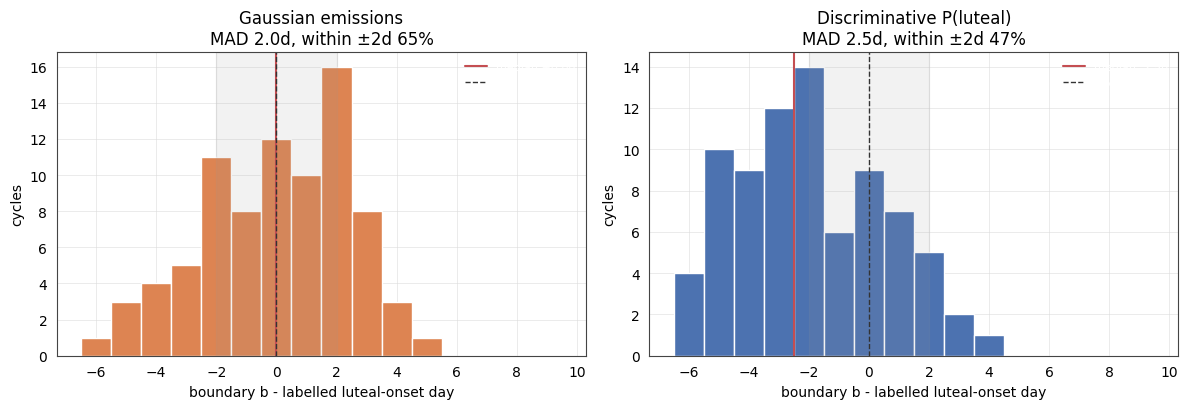

In [7]:
# Side-by-side: Gaussian vs discriminative emissions (pooled), against both targets.
summary = pd.DataFrame({
    ("LH peak", "Gaussian"):        metrics(res_pooled, "ov_day"),
    ("LH peak", "Discriminative"):  metrics(res_pooled_disc, "ov_day"),
    ("Luteal onset", "Gaussian"):       metrics(res_pooled, "luteal_onset"),
    ("Luteal onset", "Discriminative"): metrics(res_pooled_disc, "luteal_onset"),
}).T[["n", "bias", "MAD", "within2d", "within3d", "within2d_bc", "within3d_bc"]]
print("Pooled emissions — Gaussian vs Discriminative:")
print(summary)

# Offset from the labelled luteal onset (the primary target): Gaussian vs discriminative.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
fig.set_facecolor("white")
bins = np.arange(-6.5, 9.6, 1)
for ax, (title, res, color) in zip(
        axes, [("Gaussian emissions", res_pooled, "#dd8452"),
               ("Discriminative P(luteal)", res_pooled_disc, "#4c72b0")]):
    ax.set_facecolor("white")
    for sp in ax.spines.values():
        sp.set_color("#444444")
    ax.grid(True, color="#dddddd", lw=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    d = (res["b"] - res["luteal_onset"]).dropna()
    ax.hist(d, bins=bins, color=color, edgecolor="white")
    ax.axvline(d.median(), color="#c44e52", lw=1.5, label=f"median {d.median():+.1f}d")
    ax.axvline(0, color="#333333", ls="--", lw=1, label="luteal onset")
    ax.axvspan(-2, 2, color="#999999", alpha=0.12)
    ax.set_title(f"{title}\nMAD {(d - d.median()).abs().median():.1f}d, "
                 f"within ±2d {(d.abs() <= 2).mean() * 100:.0f}%", color="black")
    ax.set_xlabel("boundary b - labelled luteal-onset day", color="black")
    ax.set_ylabel("cycles", color="black")
    ax.tick_params(colors="black")
    ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()


## Findings

Against hormonal ground truth across **~90 confident cycles from 29 participants**:

- **The HSMM boundary is a biometric luteal-onset estimate, not exact LH ovulation.** Against the
  LH peak, pooled emissions have a median bias of **+3.5 days**: the model boundary usually lands
  several days after the hormone surge. That direction is physiologically plausible because RHR,
  HRV, and respiration shift after the ovulatory hormone event, not necessarily on the LH-peak day.
- **Pooling improves consistency but introduces a fixed lag.** Per-person emissions have smaller
  LH-peak bias (**+2 days**) but noisier timing (**MAD 3 days**). Pooled emissions have larger
  bias (**+3.5 days**) but tighter spread (**MAD 1.5 days**). After removing the fixed bias,
  pooled emissions place **51%** of cycles within ±2 days and **72%** within ±3 days of the LH peak.
- **The boundary aligns better with the study's luteal-onset label.** Against labelled luteal
  onset, pooled emissions have **0-day median bias**, **MAD 2 days**, **65% within ±2 days**, and
  **80% within ±3 days**. This supports the interpretation that the HSMM is detecting the wearable
  physiological luteal shift rather than the LH surge itself.
- **The emission directions now look physiologically correct after removing zero sentinels.**
  Pooled luteal means are higher for `resting_hr` and `avg_sleep_respiration`, and lower for
  `hrv_rmssd`, compared with follicular. The earlier apparent Fitbit RHR inversion was caused by
  stale cached daily data that still contained zero sentinel values.
- **A discriminative `P(luteal | features)` emission was prototyped** (step above) as a drop-in for
  the Gaussian, on the same standardized signals. See that step's comparison table/plot for how the
  two emission models trade off on this cohort — the classifier tends to place the boundary a little
  earlier (closer to the LH peak), while the Gaussian stays the tighter match to the luteal-onset
  label.

## Next-step levers (documented, remaining)

1. **Report two targets separately** — exact LH peak and biometric luteal onset are related but not
   identical. The model should not be described as exact ovulation unless a lag correction is
   explicitly applied.
2. **Temperature done right** — use baseline-relative/biphasic temperature features, not raw
   temperature as another Gaussian dimension.
3. **Hierarchical / partially-pooled emissions** — shrink each person toward the population mean
   instead of all-or-nothing pooling.
4. **Discriminative emissions — prototyped above (`P(luteal | features)` in the emission slot).**
   Follow-ups from here: give the classifier the richer engineered features from
   `01_discovery.ipynb` (lags/rolls/slopes) rather than the three raw `z_*` signals; make
   the fit honestly out-of-fold (leave-one-participant-out) instead of pooled-in-sample; and
   calibrate the probabilities (Platt/isotonic) so the emission scores stay meaningful.
